In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [103]:
## Let's create synthethic data points for classification
from sklearn.datasets import make_classification

In [104]:
X,y = make_classification(    # 1000 datapoints whith 2 classes
  n_samples=1000,
  n_features=2,
  n_clusters_per_class=1,
  n_redundant=00 
)

In [105]:
X

array([[-2.94372636e+00, -1.14940752e-01],
       [ 5.47619519e-01, -1.88640802e+00],
       [ 1.66781926e-03, -1.60180894e+00],
       ...,
       [ 2.40978867e-01,  2.41158927e+00],
       [ 3.68365339e-01, -1.77524556e+00],
       [-1.68844212e-01, -1.54432831e+00]])

In [106]:
y

array([0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,

In [107]:
pd.DataFrame(X)

,0,1
0,-2.943726,-0.114941
1,0.547620,-1.886408
2,0.001668,-1.601809
3,0.952015,2.194961
4,1.449218,0.161561
...,...,...
995,0.111806,1.986511
996,0.689397,-1.450161
997,0.240979,2.411589
998,0.368365,-1.775246


In [108]:
pd.DataFrame(X)[0]  ## all 0's

0     -2.943726
1      0.547620
2      0.001668
3      0.952015
4      1.449218
         ...   
995    0.111806
996    0.689397
997    0.240979
998    0.368365
999   -0.168844
Name: 0, Length: 1000, dtype: float64

In [109]:
pd.DataFrame(X)[1] ## all 1's

0     -0.114941
1     -1.886408
2     -1.601809
3      2.194961
4      0.161561
         ...   
995    1.986511
996   -1.450161
997    2.411589
998   -1.775246
999   -1.544328
Name: 1, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

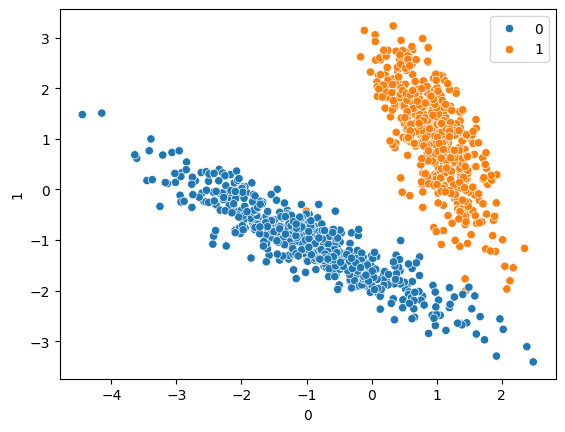

In [110]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1 ], hue = y)

In [113]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [111]:
from sklearn.svm import SVC

In [112]:
svc = SVC(
  kernel= 'linear',   ## as the datapoints are cleary seperable use linear kernel
)

In [114]:
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [115]:
## Prediciton
y_pred = svc.predict(X_test)

In [117]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       127
           1       1.00      0.98      0.99       123

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250

[[127   0]
 [  2 121]]


### If we change no. of clusters per class = 2 we will have less clear seperable dataset.
### In that case we will use RBF kernel

In [158]:
X,y = make_classification(    # 1000 datapoints whith 2 classes
  n_samples=1000,
  n_features=2,
  n_clusters_per_class=2,
  n_redundant=00 
)

<Axes: xlabel='0', ylabel='1'>

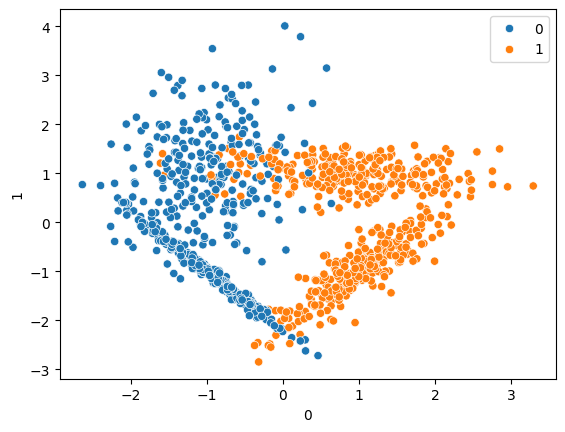

In [159]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1 ], hue = y)

In [160]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [161]:
from sklearn.svm import SVC

svc = SVC(
  kernel= 'rbf',   ## as the datapoints are not cleary seperable use RBF kernel
)

In [162]:
svc.fit(X_train, y_train)

SVC()

In [163]:
## Prediciton
y_pred = svc.predict(X_test)

In [164]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.95      0.93       120
           1       0.95      0.91      0.93       130

    accuracy                           0.93       250
   macro avg       0.93      0.93      0.93       250
weighted avg       0.93      0.93      0.93       250

[[114   6]
 [ 12 118]]


### If polynomial kernel

In [165]:
from sklearn.svm import SVC

svc = SVC(
  kernel= 'poly',   ## as the datapoints are not cleary seperable use RBF kernel
)

svc.fit(X_train, y_train)

## Prediciton
y_pred = svc.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       120
           1       0.92      0.92      0.92       130

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[110  10]
 [ 10 120]]


### If sigmoid

In [166]:
from sklearn.svm import SVC

svc = SVC(
  kernel= 'sigmoid',   ## as the datapoints are not cleary seperable use RBF kernel
)

svc.fit(X_train, y_train)

## Prediciton
y_pred = svc.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       120
           1       0.87      0.80      0.84       130

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250

[[105  15]
 [ 26 104]]


## Once we have selected the best kernel
## Let's perfrom Hyperparameter tuning

In [167]:
from sklearn.model_selection import GridSearchCV

# defining paramter range
param_grid = {
  'C' : [0.1, 1, 10, 100, 1000],
  'gamma' : [1, 0.1, 0.01, 0.001, 0.0001],
  'kernel' : ['rbf']
}

In [168]:
grid = GridSearchCV(
  SVC(),
  param_grid=param_grid,
  cv=5,
  refit=True,
  verbose=3
)

In [169]:
grid

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [170]:
grid.fit(
  X_train, y_train
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.940 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.953 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.940 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.953 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.940 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [171]:
grid.best_params_

{'C': 1000, 'gamma': 1, 'kernel': 'rbf'}

In [172]:
## Prediciton
y_pred = svc.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       120
           1       0.87      0.80      0.84       130

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250

[[105  15]
 [ 26 104]]
